# A first look at our YouTube comments

Before training a model, I want to understand what we actually downloaded.
Are the comments usable? Do the labels agree with each other? Has the supplied
cleaning removed anything we need?

We will work through those questions using the full CSV. A few plots and word
counts use smaller, reproducible samples, and those cells say so explicitly.
Each section has a short explanation, the code, and a note about what the result
means for our project.

At the end, we will have a small audit report and 200 comments to review by hand.
The raw dataset stays untouched. We will decide on ingestion, validation, and
preprocessing after reviewing these findings.

## 1. Get the notebook ready

Open this notebook in VS Code and select the project's `.venv` Python interpreter.
Run the cells from top to bottom. Loading the whole CSV takes a few seconds and
uses more memory than working with a sample.

If the notebook packages are missing, run this in a terminal at the repository root:

```powershell
uv pip install --python .venv/Scripts/python.exe -r requirements-eda.txt
```

If the CSV is missing on a new checkout, restore it with:

```powershell
.\.venv\Scripts\python.exe -m dvc pull data/raw/youtube-comments-sentiment.csv.dvc
```

The analysis itself reads the local CSV and needs no AWS credentials.

In [1]:
from pathlib import Path
import os

# This works when the notebook starts in either the repo or notebooks/.
current_folder = Path.cwd().resolve()
PROJECT_ROOT = next(
    (folder for folder in [current_folder, *current_folder.parents]
     if (folder / "config/config.yaml").is_file()
     and (folder / ".dvc").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open the notebook from this repository or its notebooks folder.")

# Keep the plot font cache in the local, Git-ignored environment.
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".venv/.matplotlib"))

'E:\\Ai-sys\\youtube_Comment_analyzer\\.venv\\.matplotlib'

In [2]:
import hashlib
import json
import re
from collections import Counter
from importlib.metadata import version
from textwrap import shorten

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import Markdown, display

%matplotlib inline

SEED = 42
PLOT_SAMPLE_SIZE = 50_000
REVIEW_SAMPLE_SIZE = 200
SENTIMENT_ORDER = ["Negative", "Neutral", "Positive"]
COLORS = {"Negative": "#bb5555", "Neutral": "#858b94", "Positive": "#43866c"}

pd.set_option("display.max_colwidth", 130)
pd.set_option("display.max_rows", 15)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

`SEED` makes our samples repeatable. If two people use the same file, package
versions, and seed, they should get the same sampled rows. This is useful when
we want to discuss one particular comment or compare results later.

In [3]:
packages = ["pandas", "numpy", "matplotlib", "seaborn", "nbformat", "nbclient", "ipykernel", "PyYAML"]
package_versions = {package: version(package) for package in packages}
display(pd.Series(package_versions, name="Installed version").to_frame())

,Installed version
pandas,2.3.3
numpy,2.5.3
matplotlib,3.11.2
seaborn,0.13.2
nbformat,5.11.1
nbclient,0.10.4
ipykernel,6.31.0
PyYAML,6.0.3


## 2. Check which file we are studying

The dataset is [Arshia82sbn/youtube-sentiment-dataset](https://huggingface.co/datasets/Arshia82sbn/youtube-sentiment-dataset).
The download revision and expected checksum are recorded in `config/config.yaml`.

The checksum answers a simple question: are we analysing the same bytes that
we downloaded? It does not tell us whether the sentiment labels are correct.

In [4]:
with (PROJECT_ROOT / "config/config.yaml").open(encoding="utf-8") as file:
    config = yaml.safe_load(file)

dataset = config["dataset"]
RAW_PATH = PROJECT_ROOT / dataset["raw_path"]
TEXT = dataset["columns"]["text"]
TITLE = dataset["columns"]["video_title"]
SENTIMENT = dataset["columns"]["sentiment"]
TARGET = dataset["columns"]["target"]
LABEL_MAP = {int(number): label for number, label in dataset["label_mapping"].items()}

if not RAW_PATH.is_file():
    raise FileNotFoundError("The raw CSV is missing. Run the dvc pull command shown above.")

with RAW_PATH.open("rb") as file:
    raw_sha256 = hashlib.file_digest(file, "sha256").hexdigest()

assert raw_sha256 == dataset["source"]["sha256"], "The CSV differs from the configured source."
assert RAW_PATH.stat().st_size == dataset["source"]["size_bytes"], "Unexpected file size."

display(pd.Series({
    "Dataset": dataset["name"],
    "Revision": dataset["source"]["revision"],
    "File size (MB, decimal)": round(RAW_PATH.stat().st_size / 1_000_000, 1),
    "SHA-256 matches": True,
}, name="Source check").to_frame())

,Source check
Dataset,Arshia82sbn/youtube-sentiment-dataset
Revision,7561b9e5d8f8054d085e0dd50bb29b0fe2e8cb1e
"File size (MB, decimal)",445.5
SHA-256 matches,True


## 3. Load the CSV and look at the columns

I am reading every column as text first. That lets us inspect a malformed label
instead of having the CSV reader fail while converting it to an integer.

There is one small detail worth understanding: pandas normally treats strings
such as `NA` and `NULL` as missing values. Those could be real comments. Here,
only an empty CSV field counts as missing. We check whitespace-only text separately.

In [5]:
df = pd.read_csv(
    RAW_PATH,
    dtype="string",
    encoding=dataset["encoding"],
    keep_default_na=False,
    na_values=[""],
)

required_columns = [TEXT, TITLE, SENTIMENT, TARGET, "clean_comment_text"]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"DataFrame memory: {df.memory_usage(deep=True).sum() / 1_000_000:,.0f} MB")
display(df.sample(5, random_state=SEED)[[TITLE, TEXT, SENTIMENT, TARGET]])

Rows: 1,032,225
Columns: 8
DataFrame memory: 930 MB


,VideoTitle,CommentText,Sentiment,Sentiment_label
986142,C pointers explained👉,This video was quite hard to follow and understand.,Negative,0
865071,SHAPIRO: 5 Reasons Why CNN Is Fake News,Love your show ❤️ 🤍💙 and appreciate your courageous platform. We thank you. TRUMP2024 🇺🇸🇺🇸🇺🇸,Positive,2
991085,3 Mini Python Projects - For Intermediates,what color theme do you use \nPlease tell me,Neutral,1
105074,Mugshot Comes Back To Haunt Congressman Matt Gaetz During Impeachment Inquiry,The one's who CRY ABOUT ANYTHING THAT THEY HAVE DONE... But!!!\nIF SOMEONE ELSE DOES THE VERY SAME THING....\nTHEN AND ONLY TH...,Negative,0
698649,PBBM GALIT NA KAY DIGONG! DUTERTE BAKIT PIKON NA PIKON KAY BBM? IMEE MARCOS KAY DIGONG PA PUMANIG!,Mr. Duterte.. magpahinga ka na please.. gayahin mo si president biden.. give way na kaagad kay Tramp..,Neutral,1


The first few rows can give a misleading impression, so the preview above is a
random sample. It is still too small to represent the whole dataset.

Here is how I will treat the columns:

| Columns | Role in this notebook |
| --- | --- |
| `CommentText` | Original comment. Our main source for text analysis. |
| `VideoTitle` | Available video context and a possible grouping key. |
| `Sentiment`, `Sentiment_label` | Two representations of the provided target. |
| `clean_comment_text`, `clean_title` | Publisher-supplied transformations to inspect. |
| `tokens_comment_text`, `token_title` | Stored text representations of token lists. |

We do not need to evaluate the token-list strings as Python code. The file has
no video IDs, timestamps, or channel IDs, so it cannot support a time-based
split or a reliable channel-level analysis on its own.

In [6]:
empty_fields = df.isna().sum()
whitespace_only = pd.Series({
    column: int((df[column].notna() & df[column].fillna("").str.fullmatch(r"\s*")).sum())
    for column in df.columns
})

missing_table = pd.DataFrame({
    "Empty CSV fields": empty_fields,
    "Whitespace-only values": whitespace_only,
    "Empty or whitespace (%)": (empty_fields + whitespace_only) / len(df) * 100,
})
display(missing_table.round(3))

,Empty CSV fields,Whitespace-only values,Empty or whitespace (%)
VideoTitle,0,0,0.000
CommentText,0,161,0.016
Sentiment,0,0,0.000
Sentiment_label,0,0,0.000
clean_comment_text,31225,0,3.025
tokens_comment_text,0,0,0.000
clean_title,8065,0,0.781
token_title,0,0,0.000


Notice the difference between a missing raw comment and an empty cleaned comment.
The raw input can be useful even when a transformation has erased its content.
We will look at actual examples before deciding whether to discard anything.

## 4. Check the labels, then count the classes

Our configuration maps `0` to Negative, `1` to Neutral, and `2` to Positive.
I want to check both the allowed numbers and the agreement between the two target
columns. A correct mapping still says nothing about annotation quality.

In [7]:
label_number = pd.to_numeric(df[TARGET], errors="coerce")
expected_sentiment = label_number.map(LABEL_MAP)
provided_sentiment = df[SENTIMENT].str.strip()

invalid_number = ~label_number.isin(LABEL_MAP)
label_mismatch = ~provided_sentiment.eq(expected_sentiment).fillna(False)
valid_label = ~invalid_number & ~label_mismatch

display(pd.Series({
    "Invalid or missing numeric labels": int(invalid_number.sum()),
    "Text/numeric label disagreement": int(label_mismatch.sum()),
    "Rows with consistent allowed labels": int(valid_label.sum()),
}, name="Rows").to_frame())
display(pd.crosstab(provided_sentiment, label_number, dropna=False))

,Rows
Invalid or missing numeric labels,0
Text/numeric label disagreement,0
Rows with consistent allowed labels,1032225


Sentiment_label,0,1,2
Sentiment,,,
Negative,346075,0,0
Neutral,0,342833,0
Positive,0,0,343317


,Comments,Share of all rows (%)
Sentiment,,
Negative,346075,33.53
Neutral,342833,33.21
Positive,343317,33.26


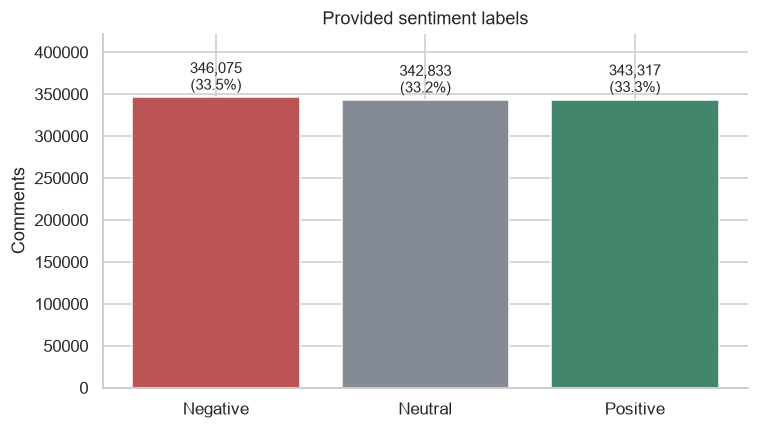

In [8]:
class_counts = provided_sentiment[valid_label].value_counts().reindex(SENTIMENT_ORDER, fill_value=0)
class_summary = pd.DataFrame({
    "Comments": class_counts,
    "Share of all rows (%)": class_counts / len(df) * 100,
})
display(class_summary.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_counts.index, class_counts.values, color=[COLORS[label] for label in class_counts.index])
for bar, count in zip(bars, class_counts):
    ax.annotate(f"{count:,}\n({count / len(df):.1%})",
                (bar.get_x() + bar.get_width() / 2, count),
                xytext=(0, 5), textcoords="offset points", ha="center", fontsize=10)
ax.set(title="Provided sentiment labels", ylabel="Comments", ylim=(0, class_counts.max() * 1.22))
ax.ticklabel_format(style="plain", axis="y")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The classes are close to balanced in this file. That makes class imbalance less
urgent for a first baseline, but we should still report results for each class.
Real comments on one YouTube video may have a very different distribution.

**Pause here:** if a model always predicted the largest class, what fraction of
these rows would it get right? That fraction is a useful reference point. It is
not a measured test-set result.

In [9]:
print(f"Largest class: {class_counts.idxmax()}")
print(f"Largest-class share of this file: {class_counts.max() / len(df):.2%}")

Largest class: Negative
Largest-class share of this file: 33.53%


## 5. Separate repeated rows from repeated comments

An exact duplicate repeats all eight fields. A repeated comment is different:
people can write the same short message on several videos.

For this audit, I will make a comparison key by removing extra whitespace and
ignoring letter case. Punctuation, emojis, and negation remain in the key.
This key is for counting and grouping. We are not choosing model preprocessing yet.

In [10]:
raw_text = df[TEXT].fillna("")
comment_key = raw_text.str.replace(r"\s+", " ", regex=True).str.strip().str.casefold()
title_key = df[TITLE].fillna("").str.replace(r"\s+", " ", regex=True).str.strip().str.casefold()
nonempty_text = comment_key.ne("")

# Keep this analysis table separate from the original DataFrame.
audit = pd.DataFrame({
    "source_row": df.index,
    "comment_key": comment_key,
    "title_key": title_key,
    "sentiment": expected_sentiment,
    "characters": raw_text.str.len(),
    "whitespace_tokens": raw_text.str.count(r"\S+"),
})
valid_audit = audit.loc[nonempty_text & valid_label]

exact_duplicate_rows = int(df.duplicated().sum())
repeated_comment_rows = int(comment_key[nonempty_text].duplicated().sum())
display(pd.Series({
    "Whitespace-only raw comments": int((~nonempty_text).sum()),
    "Exact duplicate rows beyond the first": exact_duplicate_rows,
    "Repeated comment keys beyond the first": repeated_comment_rows,
    "Distinct nonempty comment keys": int(comment_key[nonempty_text].nunique()),
}, name="Count").to_frame())

,Count
Whitespace-only raw comments,161
Exact duplicate rows beyond the first,12241
Repeated comment keys beyond the first,47086
Distinct nonempty comment keys,984978


In [11]:
repeated_comments = valid_audit.groupby("comment_key").agg(
    rows=("source_row", "size"),
    distinct_titles=("title_key", "nunique"),
    distinct_labels=("sentiment", "nunique"),
).sort_values("rows", ascending=False)
display(repeated_comments.head(8))

,rows,distinct_titles,distinct_labels
comment_key,,,
❤,1169,590,2
thanks,781,580,2
thank you,597,481,2
thanks!,531,420,2
❤❤❤,455,283,2
nice,436,357,2
😂😂😂,423,262,2
😂,417,273,2


We have 12,241 exact duplicate rows and 47,086 repeated comment occurrences beyond
the first, using the comparison key above. Those are different counts and they
overlap. We should not add them together as if they were separate rejected rows.

Short repeated comments need context. A message such as “thank you” can be a
perfectly normal response on many videos. Exact copied records are easier to
justify removing than every repeated phrase.

## 6. Look for conflicting labels

The same text can express something different under a different video title.
First we count disagreements across any context. Then we use the available
title and comment together, which is the more specific check.

A title is only a proxy for a video ID. Two videos can share a title, so even a
conflicting title/comment pair needs inspection before we call it an annotation error.

In [12]:
labels_per_comment = valid_audit.groupby("comment_key")["sentiment"].nunique()
labels_per_context = valid_audit.groupby(["title_key", "comment_key"])["sentiment"].nunique()
conflicting_comments = labels_per_comment[labels_per_comment.gt(1)]
conflicting_contexts = labels_per_context[labels_per_context.gt(1)]

context_index = pd.MultiIndex.from_frame(valid_audit[["title_key", "comment_key"]])
context_conflict_mask = context_index.isin(conflicting_contexts.index)
context_conflict_rows = int(context_conflict_mask.sum())

display(pd.Series({
    "Comment keys with multiple labels across all titles": len(conflicting_comments),
    "Title/comment pairs with multiple labels": len(conflicting_contexts),
    "Rows in those conflicting title/comment pairs": context_conflict_rows,
}, name="Count").to_frame())

,Count
Comment keys with multiple labels across all titles,1941
Title/comment pairs with multiple labels,705
Rows in those conflicting title/comment pairs,2717


In [13]:
# Show a few complete groups, so the disagreement is visible.
if len(conflicting_contexts):
    example_contexts = conflicting_contexts.head(3).index
    example_mask = context_index.isin(example_contexts)
    example_rows = valid_audit.index[example_mask]
    display(df.loc[example_rows, [TITLE, TEXT, SENTIMENT, TARGET]].head(12))
else:
    print("No conflicting title/comment pairs were found with this comparison rule.")

,VideoTitle,CommentText,Sentiment,Sentiment_label
23011,"""Bart's First Day of Kindergarten""","""even me?""\n""no""",Neutral,1
215528,"""Bart's First Day of Kindergarten""","""Even me?"" ""no""",Negative,0
739120,"""Eats for three"" 😂 | Young Sheldon Edit",Dayum,Neutral,1
798961,"""Bart's First Day of Kindergarten""",Even me no,Negative,0
863286,"""Eats for three"" 😂 | Young Sheldon Edit",DAYUM,Positive,2
865450,"""Bart's First Day of Kindergarten""",Even me no,Neutral,1
897397,"""Bart's First Day of Kindergarten""","""even me?"" ""no""",Neutral,1


There are 705 conflicting title/comment pairs. The examples make this more useful
than a count alone: we can see which records would need a decision.

For the later pipeline, my proposal is to flag these groups for review. Keeping
an arbitrary first label or taking a majority vote would silently invent a label
policy. We should agree on that policy before implementing it.

## 7. Compare the supplied cleaned text with the original

Cleaning can help a model, but it can also remove meaning. Let us start with the
simplest case: a real raw comment becoming empty after cleaning.

In [14]:
clean_text = df["clean_comment_text"].fillna("")
empty_cleaned = clean_text.str.strip().eq("")
raw_but_no_cleaned = nonempty_text & empty_cleaned

print(f"Nonempty raw comments with empty cleaned text: {raw_but_no_cleaned.sum():,}")
display(df.loc[raw_but_no_cleaned, [TEXT, "clean_comment_text", SENTIMENT]].sample(
    min(6, int(raw_but_no_cleaned.sum())), random_state=SEED,
))

Nonempty raw comments with empty cleaned text: 31,064


,CommentText,clean_comment_text,Sentiment
221246,whatever before or after or anything,<NA>,Neutral
417208,❤🎉🎉🎉,<NA>,Positive
898355,❤❤❤❤,<NA>,Positive
416006,♥️🇺🇦♥️🇺🇦🙏,<NA>,Positive
74327,How did I get here,<NA>,Neutral
289951,❤,<NA>,Positive


The cleaned field is empty for 31,064 nonempty raw comments. An emoji-only reaction
can still express sentiment, so an empty cleaned field is not enough evidence to
reject the original comment.

Now let us look for comments containing a few common English negation terms.
The regular expression below is a screening rule, not a complete grammar model.
Contractions and transformed wording can make this check imperfect.

In [15]:
NEGATION_PATTERN = r"\b(?:no|not|never|don't|can't|won't|isn't|wasn't|didn't|without)\b"
raw_has_negation = raw_text.str.contains(NEGATION_PATTERN, case=False, regex=True)
clean_has_negation = clean_text.str.contains(NEGATION_PATTERN, case=False, regex=True)
negation_change_candidates = raw_has_negation & ~clean_has_negation

print(f"Rows to inspect for a changed negation cue: {negation_change_candidates.sum():,}")
display(df.loc[negation_change_candidates, [TEXT, "clean_comment_text", SENTIMENT]].sample(
    min(6, int(negation_change_candidates.sum())), random_state=SEED,
))

Rows to inspect for a changed negation cue: 199,081


,CommentText,clean_comment_text,Sentiment
937303,"I follow what the Bible says for my life everyday. Each person must decide, on their own whether or not they will follow the p...",follow bible say life everyday person decide follow path lead god,Neutral
117024,Just wondering! How come bacon eaters are more peaceful than those who must not eat bacon?,wonder come bacon eater peaceful eat bacon,Neutral
887408,Crowder never comments when I write on here...... Hehe,crowder comment write hehe,Neutral
245403,Why 500k and not 250k or a little more why so much more,500k 250k little,Neutral
337498,"They 'NEED' (no they don't) your credit card, not because you ""might exceed"" their free tiers, but because when you hit one of...",need credit card exceed free tier hit pay wall know easy approve purchase enter card info time think call social engineering,Negative
397226,"Cute little Jaguar which will eventually have a stronger bite force than a Lion, Tiger, Kodiak, Grizzly or Polar Bear. The Jag...",cute little jaguar eventually strong bite force lion tiger kodiak grizzly polar bear jaguar cat suffocate prey instead bite sk...,Positive


A count from this rule is not proof that every row lost its meaning. Read the
examples. The useful decision is that we should start from `CommentText` and
make our own cleaning choices after review, rather than assume the supplied
cleaned column is suitable for our model.

**Try this:** find a sentence containing “not”. Read it again without that word.
Does the sentiment stay the same? That is why a generic stopword list can be risky.

## 8. Measure comment length

Character length counts Unicode code points. The second measure counts tokens
separated by whitespace. That token count includes things such as emojis and URLs,
so I will not call it a linguistic word count.

Percentiles are helpful here: the median describes a typical comment, while the
99th percentile and maximum show the long tail.

In [16]:
length_summary = audit.loc[nonempty_text, ["characters", "whitespace_tokens"]].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99],
)
display(length_summary.round(1))

,characters,whitespace_tokens
count,1032064.0,1032064.0
mean,107.1,19.2
std,178.2,30.1
min,1.0,1.0
50%,65.0,12.0
90%,221.0,40.0
95%,326.0,58.0
99%,719.0,124.0
max,9997.0,1796.0


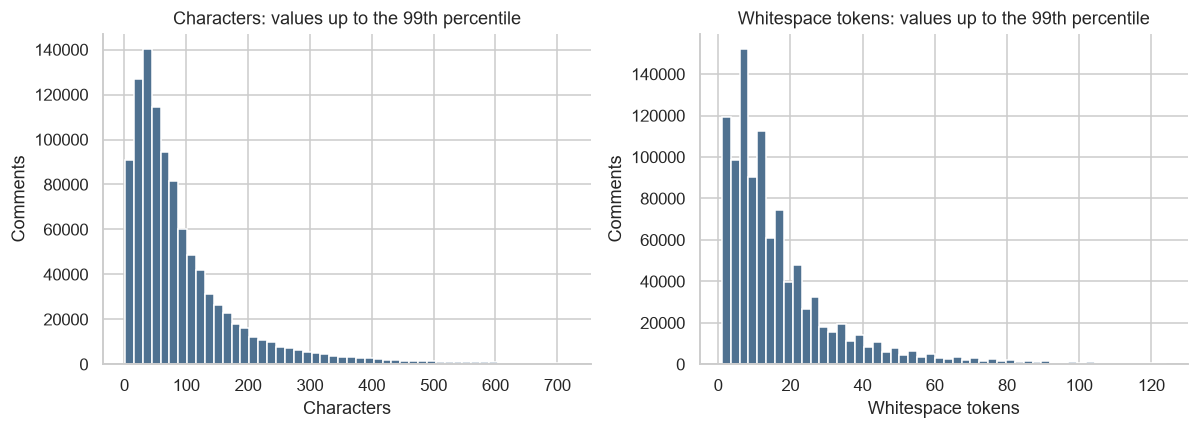

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, column, label in zip(axes, ["characters", "whitespace_tokens"], ["Characters", "Whitespace tokens"]):
    values = audit.loc[nonempty_text, column]
    limit = values.quantile(0.99)
    ax.hist(values[values.le(limit)], bins=50, color="#4f7190", edgecolor="white")
    ax.set(title=f"{label}: values up to the 99th percentile", xlabel=label, ylabel="Comments")
    ax.ticklabel_format(style="plain", axis="y")
sns.despine()
plt.tight_layout()
plt.show()

The histograms above hide values beyond the 99th percentile to keep the main
distribution readable. The summary table still includes every nonempty comment.
Long comments will matter when we choose a model's input limit later.

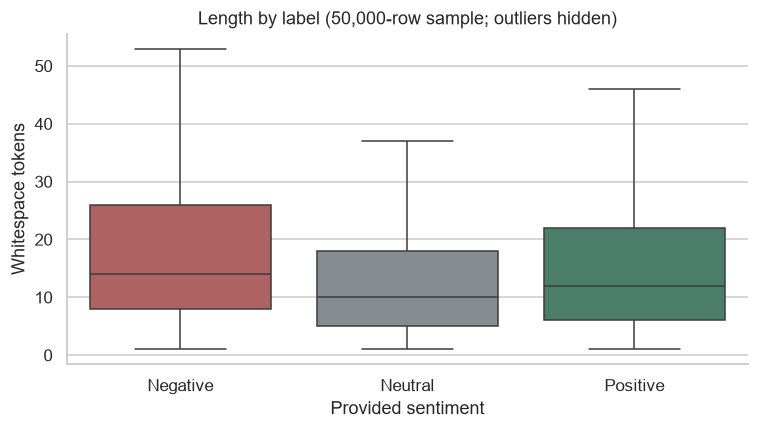

In [18]:
plot_sample = valid_audit.sample(min(PLOT_SAMPLE_SIZE, len(valid_audit)), random_state=SEED)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=plot_sample, x="sentiment", y="whitespace_tokens", hue="sentiment",
            order=SENTIMENT_ORDER, hue_order=SENTIMENT_ORDER, palette=COLORS,
            legend=False, showfliers=False, ax=ax)
ax.set(title=f"Length by label ({len(plot_sample):,}-row sample; outliers hidden)",
       xlabel="Provided sentiment", ylabel="Whitespace tokens")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The line inside a box is the median. The box covers the middle 50% of observations.
This plot lets us compare length across labels. It does not show that length
causes a comment to be positive or negative.

## 9. Check a few features of informal comments

YouTube text often includes timestamps, mentions, links, and reactions.
These patterns are useful for deciding what to preserve or standardize later.

The emoji/symbol pattern is deliberately broad. It detects several emoji and
symbol ranges, but it is not a complete Unicode emoji parser. These are screening
counts, not moderation or spam labels.

In [19]:
EMOJI_SYMBOL_PATTERN = r"[\U0001F000-\U0001FAFF\u2600-\u27BF]"
feature_patterns = {
    "Emoji or symbol signal": EMOJI_SYMBOL_PATTERN,
    "URL": r"(?:https?://|www\.)\S+",
    "Mention": r"@\w+",
    "Timestamp-like text": r"(?<!\d)\d{1,2}:\d{2}(?::\d{2})?(?!\d)",
    "English negation cue": NEGATION_PATTERN,
}
text_features = pd.DataFrame({
    name: raw_text.str.contains(pattern, case=False, regex=True)
    for name, pattern in feature_patterns.items()
})
text_features["No Unicode letters"] = nonempty_text & ~raw_text.str.contains(r"[^\W\d_]", regex=True)
feature_summary = pd.DataFrame({
    "Comments": text_features.sum(),
    "Share of all rows (%)": text_features.mean() * 100,
})
display(feature_summary.round(2))

,Comments,Share of all rows (%)
Emoji or symbol signal,213867,20.72
URL,1557,0.15
Mention,3435,0.33
Timestamp-like text,21473,2.08
English negation cue,202769,19.64
No Unicode letters,19902,1.93


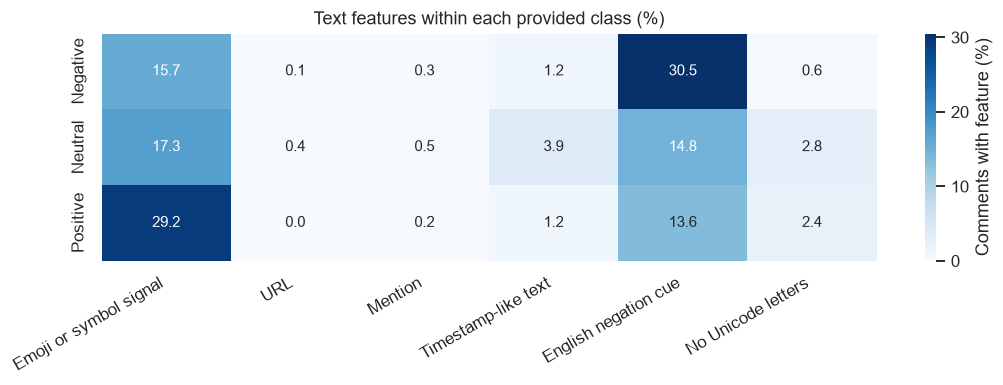

In [20]:
features_by_label = text_features.loc[valid_label].groupby(expected_sentiment[valid_label]).mean()
features_by_label = (features_by_label.reindex(SENTIMENT_ORDER) * 100).astype(float)

fig, ax = plt.subplots(figsize=(10, 3.6))
sns.heatmap(features_by_label, annot=True, fmt=".1f", cmap="Blues", vmin=0,
            cbar_kws={"label": "Comments with feature (%)"}, ax=ax)
ax.set(title="Text features within each provided class (%)", xlabel="", ylabel="")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Each heatmap cell uses its own sentiment class as the denominator. A comment can
match several features, so the percentages are not supposed to add up to 100%.
“No Unicode letters” includes emoji, punctuation, and numeric comments. It is
broader than “emoji-only”.

## 10. Look at writing systems without guessing a language

The dataset card describes the file as English. We should inspect that claim
instead of using it as an automatic filter.

The patterns below find Unicode blocks associated with several writing systems.
A block can contain digits or punctuation as well as letters. A comment can match
more than one block. These flags do not identify a language, and Roman-script
Hinglish or other languages can pass an English-looking script check.

In [21]:
script_patterns = {
    "Devanagari block": r"[\u0900-\u097F]",
    "Bengali block": r"[\u0980-\u09FF]",
    "Arabic block": r"[\u0600-\u06FF]",
    "Cyrillic block": r"[\u0400-\u04FF]",
    "CJK ideographs": r"[\u4E00-\u9FFF]",
    "Hangul syllables": r"[\uAC00-\uD7AF]",
}
script_flags = pd.DataFrame({
    name: raw_text.str.contains(pattern, regex=True)
    for name, pattern in script_patterns.items()
})
script_summary = pd.DataFrame({
    "Comments matching block": script_flags.sum(),
    "Share of all rows (%)": script_flags.mean() * 100,
})
display(script_summary.round(3))

script_example_mask = script_flags.any(axis=1)
if script_example_mask.any():
    display(df.loc[script_example_mask, [TEXT, SENTIMENT]].sample(
        min(5, int(script_example_mask.sum())), random_state=SEED,
    ))

,Comments matching block,Share of all rows (%)
Devanagari block,701,0.068
Bengali block,79,0.008
Arabic block,1886,0.183
Cyrillic block,10542,1.021
CJK ideographs,1729,0.168
Hangul syllables,1191,0.115


,CommentText,Sentiment
297534,Я бы 2 года догонял,Neutral
7905,Уютная пещерка))и никакого интернета)),Positive
735909,Это кто так делает? Какая страна?,Neutral
179239,這個縱火者在鏡頭前拿著噴火器，在光天白日，給民衆抓到，會不會是一個太明顯的被罪疚者呢？,Neutral
608266,عالی,Neutral


The examples are enough to question an assumption that every row is English.
They do not give us reliable language proportions. If V1 will support English
only, we will need a language policy that also handles short and mixed-language
comments. We should review that policy before filtering rows.

## 11. Check how comments are distributed across titles

We have many comments per title. If a few titles dominated the file, a model
could learn their topics instead of general sentiment. I will inspect both
the distribution and the ten most frequent titles.

Distinct normalized nonempty titles: 4,564
Rows from the ten most frequent titles: 1.00%


,Comments per title
count,4564.0
mean,226.2
std,116.2
min,1.0
50%,209.0
90%,336.7
99%,701.7
max,1192.0


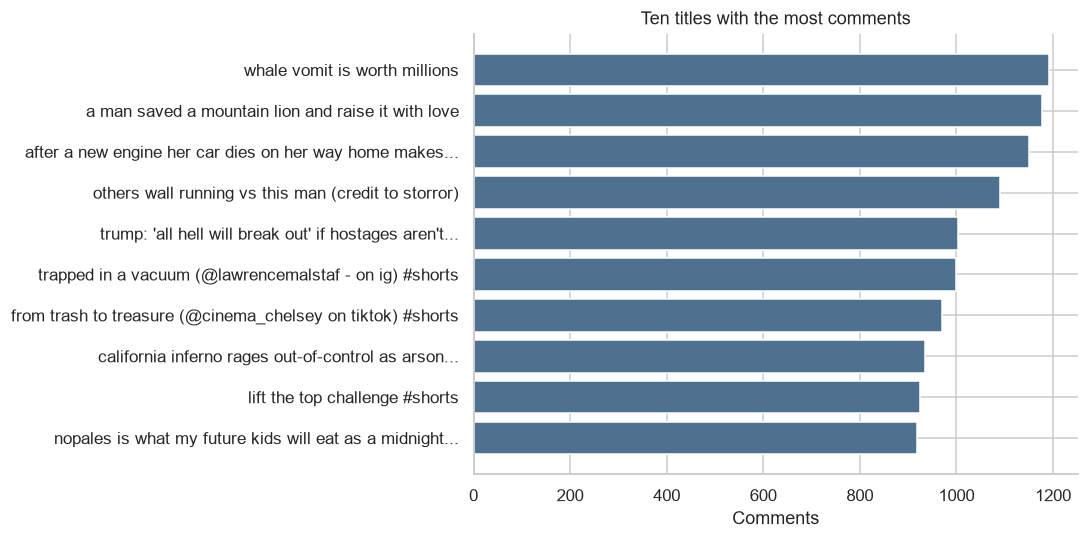

In [22]:
title_counts = title_key[title_key.ne("")].value_counts()
top10_title_share = title_counts.head(10).sum() / len(df) * 100

print(f"Distinct normalized nonempty titles: {len(title_counts):,}")
print(f"Rows from the ten most frequent titles: {top10_title_share:.2f}%")
display(title_counts.describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_frame("Comments per title"))

top_titles = title_counts.head(10).sort_values()
# Remove unsupported emoji from chart labels only, so the labels render clearly.
plot_titles = [shorten(re.sub(EMOJI_SYMBOL_PATTERN, "", title), width=58, placeholder="...")
               for title in top_titles.index]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_titles, top_titles.values, color="#4f7190")
ax.set(title="Ten titles with the most comments", xlabel="Comments", ylabel="")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Titles are useful context, but they are imperfect identifiers. The 4,564 distinct
normalized titles are not a verified count of distinct videos. We also cannot
measure channel balance because channel IDs are not present.

## 12. Demonstrate why a random row split can leak information

This is a diagnostic experiment, not our final training split. I will temporarily
assign 80% of usable rows to one side and 20% to the other, then check overlap.
No model is trained and no split files are written.

If the same titles occur on both sides, a context-aware model is being evaluated
on videos it may effectively have seen during training. Repeated comment text
can create another kind of overlap.

In [23]:
split_demo = valid_audit.loc[valid_audit["title_key"].ne("")]
rng = np.random.default_rng(SEED)
random_order = rng.permutation(len(split_demo))
cutoff = int(len(split_demo) * 0.8)
train_demo = split_demo.iloc[random_order[:cutoff]]
holdout_demo = split_demo.iloc[random_order[cutoff:]]

seen_titles = holdout_demo["title_key"].isin(train_demo["title_key"])
seen_comments = holdout_demo["comment_key"].isin(train_demo["comment_key"])
overlap_summary = pd.DataFrame({
    "Holdout rows with overlap": [int(seen_titles.sum()), int(seen_comments.sum())],
    "Share of holdout rows (%)": [seen_titles.mean() * 100, seen_comments.mean() * 100],
}, index=["Title also in training side", "Comment key also in training side"])
display(overlap_summary.round(2))

,Holdout rows with overlap,Share of holdout rows (%)
Title also in training side,206413,100.00
Comment key also in training side,11382,5.51


For the actual experiment, I propose splitting by available title groups and
checking repeated text across the resulting splits. Title grouping reduces
context overlap, but cannot fully solve repeated phrases across different titles.
We will also have to check whether class balance survives the grouped split.

With seed 42, every holdout row shares its title with the training side, and
about 5.51% share a comment key. This does not prove how much a particular model
would benefit from the overlap. It shows why we need to choose the split before
trusting a reported model score.

**Try this:** change `SEED`, rerun just the diagnostic split cell, and compare
the overlap. A new random seed does not fix a grouping problem.

## 13. Explore common words on a reproducible sample

Counting words in a sample gives us a quick view of recurring vocabulary. This
section uses at most 50,000 usable comments, sampled uniformly across usable rows.
It does not use the entire dataset.

The tokenizer below only extracts ASCII letter words, with optional apostrophes.
It will miss other scripts. A short list of function words is excluded from this
plot so that frequent terms are easier to read. We keep negation words, and this
display rule is not a proposed training tokenizer.

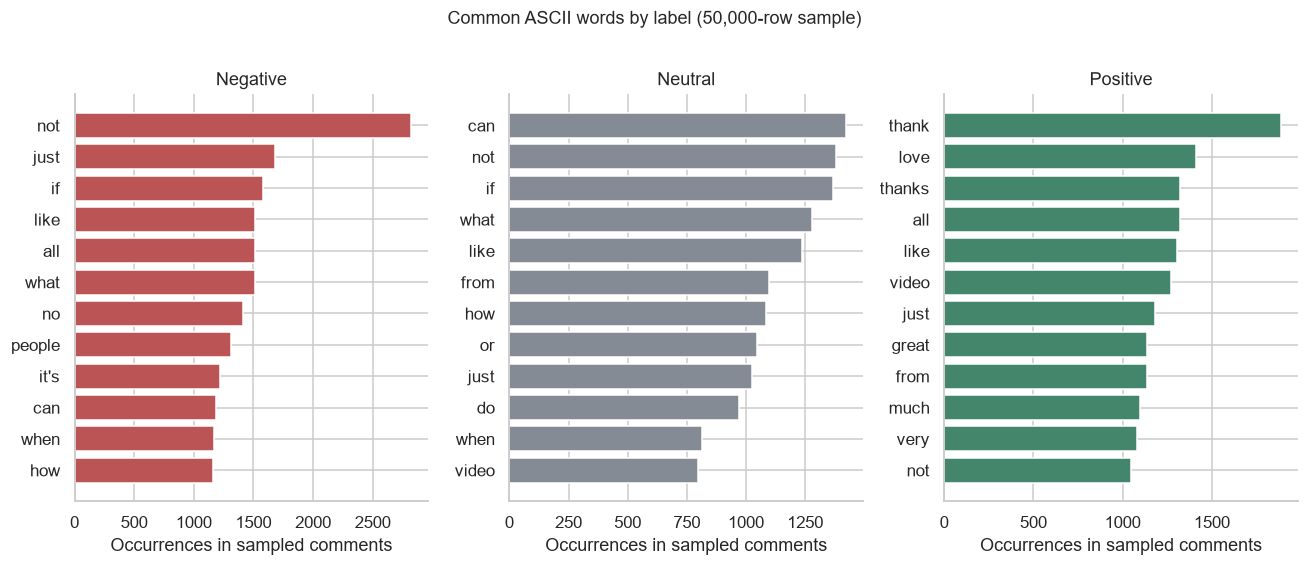

In [24]:
word_sample_rows = valid_audit.sample(min(PLOT_SAMPLE_SIZE, len(valid_audit)), random_state=SEED).index
word_sample = df.loc[word_sample_rows, [TEXT, SENTIMENT]]
display_stopwords = {
    "the", "a", "an", "and", "to", "of", "in", "is", "it", "this", "that",
    "i", "you", "for", "on", "be", "are", "was", "with", "as", "have", "my",
    "we", "they", "so", "but", "at", "your", "me", "he", "she", "s", "t",
}
word_counts = {}
for label in SENTIMENT_ORDER:
    counter = Counter()
    for text in word_sample.loc[word_sample[SENTIMENT].eq(label), TEXT]:
        words = re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())
        counter.update(word for word in words if len(word) > 1 and word not in display_stopwords)
    word_counts[label] = counter

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, label in zip(axes, SENTIMENT_ORDER):
    frequent = pd.Series(dict(word_counts[label].most_common(12))).sort_values()
    ax.barh(frequent.index, frequent.values, color=COLORS[label])
    ax.set(title=label, xlabel="Occurrences in sampled comments")
sns.despine()
fig.suptitle(f"Common ASCII words by label ({len(word_sample):,}-row sample)", y=1.02)
plt.tight_layout()
plt.show()

These bars show occurrences, so one long comment can contribute several times.
The same word can appear in every class, and video topics can influence the
counts. This plot helps us read the data. It does not tell us which features a
trained classifier will consider important.

In this sample, “not” is common in Negative comments, while “thank” and “love”
stand out in Positive comments. Notice that “not” also appears in the other
classes. A single word is a clue, not a reliable sentiment rule.

## 14. Prepare a small manual label review

Automatic checks can find contradictions. They cannot decide whether “I am
crying” expresses sadness, enjoyment, or a reaction to the video's story.

I will sample 200 distinct title/comment/label combinations, roughly equally
across the three classes. The source row index stays with each example so we can
find it again. This is the pandas row index, not a physical line number in the CSV.

Read the comment with its title and fill `reviewed_sentiment` with Negative,
Neutral, Positive, or Unclear. Use `review_notes` to explain ambiguous cases.
Try deciding before looking at the supplied label. The review has not been done
for you. A balanced review sample is useful for inspecting every class, but its
disagreement rate would not directly estimate the full dataset's label error rate.

In [25]:
review_pool = valid_audit.drop_duplicates(["title_key", "comment_key", "sentiment"])
base_count, remainder = divmod(REVIEW_SAMPLE_SIZE, len(SENTIMENT_ORDER))
review_indices = []
for position, label in enumerate(SENTIMENT_ORDER):
    class_rows = review_pool.loc[review_pool["sentiment"].eq(label)]
    requested = base_count + int(position < remainder)
    selected = class_rows.sample(min(requested, len(class_rows)), random_state=SEED)
    review_indices.extend(selected.index.tolist())

review_sample = df.loc[review_indices, [TITLE, TEXT, SENTIMENT, TARGET]].copy()
review_sample.insert(0, "source_row", review_sample.index)
review_sample["reviewed_sentiment"] = ""
review_sample["review_notes"] = ""
review_sample = review_sample.sample(frac=1, random_state=SEED).reset_index(drop=True)
display(review_sample.head(6))
print("Review sample by supplied class:")
display(review_sample[SENTIMENT].value_counts().reindex(SENTIMENT_ORDER).to_frame("Rows"))

,source_row,VideoTitle,CommentText,Sentiment,Sentiment_label,reviewed_sentiment,review_notes
0,734792,I Have A Secret Talent...2 Truths and 1 Lie (w/@MichaelKnowles),"After a long day of work, Kanye West goes to his Kanye Nest to take his Kanye Rest. He wakes up feeling his Kanye Best. Then h...",Neutral,1,,
1,691865,Top pro reloads in the biggest moments. ⁣⁣Pro paintball. ⁣⁣#paintball #shorts,American Snacker,Negative,0,,
2,181486,"C++, Java or Python? Which language is best for College Placements in India","Python learners are like, 'What do I do? Should I die?' 😂😂😂🔥",Negative,0,,
3,727777,How to learn any language easily | Matthew Youlden | TEDxClapham,"I'm México, i will try speak English, but i can teach some spanish, we can exchange our languages 👌",Positive,2,,
4,245705,Angular Material Responsive Navigation Tutorial,how do we remove the dark transition of sidenav when opened?,Neutral,1,,
5,524458,"Watch the uncensored moment Will Smith smacks Chris Rock on stage at the Oscars, drops F-bomb",Then she divorced,Neutral,1,,


Review sample by supplied class:


,Rows
Sentiment,
Negative,67
Neutral,67
Positive,66


## 15. Save the findings so we can discuss them

The next cell writes an audit report and the review worksheet under
`data/processed/eda/`. It does not export a cleaned training dataset or change the
raw CSV. These local analysis files are ignored by Git.

There is also a small rerun safeguard: if the review worksheet already exists,
the notebook leaves it in place so any labels you have entered are preserved.

In [26]:
EDA_DIR = PROJECT_ROOT / "data/processed/eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

review_path = EDA_DIR / "label_review_sample.csv"
if review_path.exists():
    print("Existing label-review worksheet preserved. Review the saved rows before changing the seed.")
else:
    review_sample.to_csv(review_path, index=False, encoding="utf-8")
    print(f"Saved {len(review_sample)} rows for manual review.")

saved_review = pd.read_csv(review_path, dtype="string", keep_default_na=False)
required_review_columns = {"source_row", TITLE, TEXT, SENTIMENT, TARGET, "reviewed_sentiment", "review_notes"}
if not required_review_columns.issubset(saved_review.columns):
    raise ValueError("The saved review worksheet is missing expected columns. Inspect it before continuing.")
if not saved_review["source_row"].str.fullmatch(r"\d+").all():
    raise ValueError("Each saved source_row must be a nonnegative integer.")
saved_indices = saved_review["source_row"].astype("int64")
if saved_indices.duplicated().any() or not saved_indices.isin(df.index).all():
    raise ValueError("The saved review contains duplicate or unavailable source rows.")
source_columns = [TITLE, TEXT, SENTIMENT, TARGET]
source_rows = df.loc[saved_indices, source_columns].reset_index(drop=True).fillna("")
if not saved_review[source_columns].equals(source_rows):
    raise ValueError("The saved review does not match this raw dataset. Inspect it before continuing.")
accepted_review_labels = ["Negative", "Neutral", "Positive", "Unclear"]
completed_review_rows = int(saved_review["reviewed_sentiment"].str.strip().isin(accepted_review_labels).sum())
print(f"Review entries completed: {completed_review_rows}/{len(saved_review)}")

Existing label-review worksheet preserved. Review the saved rows before changing the seed.
Review entries completed: 0/200


In [27]:
audit_report = {
    "dataset": dataset["name"],
    "source_revision": dataset["source"]["revision"],
    "raw_path": dataset["raw_path"],
    "sha256": raw_sha256,
    "seed": SEED,
    "package_versions": package_versions,
    "rows": len(df),
    "columns": df.columns.tolist(),
    "class_counts": {label: int(count) for label, count in class_counts.items()},
    "empty_fields": {column: int(count) for column, count in empty_fields.items()},
    "whitespace_only_raw_comments": int((~nonempty_text).sum()),
    "invalid_numeric_labels": int(invalid_number.sum()),
    "label_column_disagreement": int(label_mismatch.sum()),
    "exact_duplicate_rows_beyond_first": exact_duplicate_rows,
    "repeated_comment_rows_beyond_first": repeated_comment_rows,
    "conflicting_comment_keys": len(conflicting_comments),
    "conflicting_title_comment_pairs": len(conflicting_contexts),
    "rows_in_conflicting_title_comment_pairs": context_conflict_rows,
    "nonempty_raw_comments_with_empty_cleaned_text": int(raw_but_no_cleaned.sum()),
    "possible_negation_change_candidates": int(negation_change_candidates.sum()),
    "distinct_normalized_video_titles": len(title_counts),
    "top10_title_share_pct": float(top10_title_share),
    "random_split_holdout_title_overlap_pct": float(seen_titles.mean() * 100),
    "random_split_holdout_comment_overlap_pct": float(seen_comments.mean() * 100),
    "text_feature_counts": {name: int(count) for name, count in text_features.sum().items()},
    "script_block_counts": {name: int(count) for name, count in script_flags.sum().items()},
    "plot_sample_rows": len(plot_sample),
    "word_sample_rows": len(word_sample),
    "saved_review_rows": len(saved_review),
    "completed_manual_review_rows": completed_review_rows,
    "manual_review_complete": completed_review_rows == len(saved_review) and len(saved_review) > 0,
}
report_path = EDA_DIR / "data_audit.json"
report_path.write_text(json.dumps(audit_report, indent=2) + "\n", encoding="utf-8")
print("Saved: data/processed/eda/data_audit.json")
print("Review worksheet: data/processed/eda/label_review_sample.csv")

Saved: data/processed/eda/data_audit.json
Review worksheet: data/processed/eda/label_review_sample.csv


## 16. What I would decide before writing the pipeline

We can now make the next discussion specific.

| Observation | Proposed decision to review |
| --- | --- |
| The raw CSV has whitespace-only comments. | Reject empty raw input explicitly. |
| Some complete records are repeated. | Remove exact duplicates and record how many were removed. |
| Some title/comment pairs have conflicting labels. | Review or quarantine those groups instead of keeping an arbitrary label. |
| Useful raw comments become empty after the supplied cleaning. | Start from raw text and preserve sentiment cues. |
| The same titles cross a random row split. | Use title groups as the available proxy, then audit text overlap and class balance. |
| Comments include multiple writing systems. | Agree on how V1 handles English, other languages, and mixed-language input. |

The class balance and label mapping look suitable for trying a baseline. They do
not establish that the labels are trustworthy. The manual review is still an
open task, and we cannot calculate an independent model quality score from this
EDA alone.

The dataset card also leaves the labeling method unclear. Its metadata says
CC BY 4.0, while its usage paragraph mentions academic, research, and educational
purposes. We should resolve that wording before a commercial release.

Once we agree on the decisions above, we can implement ingestion, validation,
and preprocessing from the same rules. We have not implemented those modules here.

## References

- [Dataset card and downloadable source](https://huggingface.co/datasets/Arshia82sbn/youtube-sentiment-dataset).
  The exact revision and file checksum are recorded at the start of this notebook.
- [pandas CSV parsing and missing-value options](https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.read_csv.html).
- [scikit-learn guidance on grouped splits](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data).

All numerical findings in this notebook come from the local, checksum-verified CSV.
No model has been trained, and the manual-review fields start blank.